# Cyber Trend Forecasting - PDFormer Graph Pipeline

**Vignette Description:**
This notebook acts as the Pipeline Dashboard for the project. It handles the end-to-end workflow:
1.  **Setup:** Automatically detects if running on Google Colab or the NATO Local Server.
2.  **Training:** Executes `Train_Graph.py` to optimise the PDFormer model.
3.  **Evaluation:** Runs `Evaluate_Graph.py` to generate metrics and predictions.
4.  **Visualisation:** Runs `Visualise_Results.py` and displays the Gap Analysis inline.

## Universal Setup

This cell handles the setup logic: mounting Google Drive if on Colab, or using relative paths if on the GPU server

In [ ]:
import os
import sys
import contextlib

# --- CONFIGURATION ---
# If on Colab, ensure you have set the Secret 'project_path' to your Project Root
# e.g., /content/drive/MyDrive/NATO_Project_Root

try:
    # 1. CHECK ENVIRONMENT: Try to import Colab-specific modules
    from google.colab import drive, userdata
    IS_COLAB = True
    print("--- Detected Environment: GOOGLE COLAB ---")
except ImportError:
    IS_COLAB = False
    print("--- Detected Environment: LOCAL SERVER (NATO/BBK) ---")

# 2. PATH SETUP
if IS_COLAB:
    # --- COLAB SETUP ---
    try:
        drive.mount('/content/drive')

        # Get the PARENT ROOT from Secrets
        PROJECT_ROOT = userdata.get('project_path')
        if not PROJECT_ROOT:
            raise ValueError("Secret 'project_path' is missing.")

    except Exception as e:
        print(f"COLAB SETUP ERROR: {e}")
        # Stop execution if we can't find the files
        raise e
else:
    # --- LOCAL SETUP ---
    # We assume this notebook is in 'Notebooks/', so Root is one level up
    # os.getcwd() returns /.../Project_Root/Notebooks
    PROJECT_ROOT = os.path.abspath(os.path.join(os.getcwd(), '..'))

# 3. CONFIGURE WORKING DIRECTORY
# We need to run scripts from inside 'Transformer_Pipeline'
PIPELINE_DIR = os.path.join(PROJECT_ROOT, 'Transformer_Pipeline')

if not os.path.exists(PIPELINE_DIR):
    raise FileNotFoundError(f"Could not find pipeline folder at: {PIPELINE_DIR}")

# Change CWD to the pipeline folder so scripts can find config/data
os.chdir(PIPELINE_DIR)
print(f"SUCCESS: Working Directory set to: {os.getcwd()}")

# 4. ADD PROJECT ROOT TO SYS.PATH
# This allows us to import 'Notebooks.colab_utils' if needed
if PROJECT_ROOT not in sys.path:
    sys.path.append(PROJECT_ROOT)
    print(f"Added Project Root to sys.path: {PROJECT_ROOT}")

# 5. INSTALL DEPENDENCIES (COLAB ONLY)
if IS_COLAB:
    print("\n--- Installing Dependencies (Colab Only) ---")
    # We import the helper script from the sibling folder
    try:
        from Notebooks import Colab_Utils
        # This creates a temporary black hole for the print statements
        with open(os.devnull, 'w') as f, contextlib.redirect_stdout(f):
            Colab_Utils.setup_environment(PIPELINE_DIR)
        print("Dependencies verified successfully!")
    except ImportError:
        print("WARNING: Could not import Notebooks.colab_utils. Skipping auto-install.")

### Imports

In [2]:
from pathlib import Path

from Transformer_Pipeline.Visualise_Results import (
    visualise_evaluation_metrics,
    load_visualisation_data,
    perform_broad_analysis,
    plot_validation_forecasts,
    generate_gap_analysis_tables,
    plot_continuous_trends
)

## Optional: Re-Generate Graph Data

Run this cell if you want to rebuild the graph topology (Adjacency Matrices, Laplacian, etc.) from the raw CSV data. If you have already processed the data, you can skip this step.

In [ ]:
# Runs the preprocessing script to generate graph artifacts
# We use !python to run this as a clean subprocess

# We are currently in the 'Transformer_Pipeline' directory.
# The script will resolve paths automatically.

!python Preprocessing/Cyber_Trend_to_Graph.py --pdformer 2>/dev/null

## Step 1: Train Graph Model (PDFormer)

We now execute the training script.
* **Input:** `Cyber_Trend_Graph_Config.py` (Hyperparameters)
* **Output:** `best_model_graph.pth` (Saved weights)

We provide 2 options for training, uncomment the commends accordingly:

`%run Train_Graph.py` (Interactive): Runs the script inside this notebook's memory. This allows you to inspect variables (like model or optimiser) after execution.

`!python Train_Graph.py` (Recommended for stability): Runs the script in a separate process. This ensures a "clean slate" execution, exactly as if you were running it on a server terminal.

*Note: If running on T4 GPU, should take 15-25 minutes.*

In [ ]:
print("--- Step 1: Training PDFormer Graph Model ---")
# Option A: Interactive (keeps variables in memory)
# We use %run to execute the script in a fresh namespace.
# This runs the script as if it were in the terminal, showing live progress bars.
# This is cleaner for demo purposes than importing the main function.
%run Train_Graph.py --batch_size 4 --num_runs 10

# Option B: Clean Subprocess (Recommended for reproducibility)
# !python Train_Graph.py

## Step 2: Evaluation & Metrics

This step loads the best model saved above and runs it against the Test Set.
* It calculates **RSE, RAE, and MAE** across horizons (3, 6, 12, 24 months).
* It saves the raw predictions to `.npy` files for visualisation.
* It exports the **Column Names** metadata.

--- Step 2: Evaluating Model on Test Set ---
--- Loading Test Dataset ---
Initialising dataset for split: test from /content/drive/MyDrive/Research/NATO/code/Cyber-trend-forecasting/Processed_Data/Graph
Loading windowed data from /content/drive/MyDrive/Research/NATO/code/Cyber-trend-forecasting/Processed_Data/Graph/test.npz...
Loaded 10 samples for test.
Loading static features from /content/drive/MyDrive/Research/NATO/code/Cyber-trend-forecasting/Processed_Data/Graph...
Calculating missing Laplacian Matrix (lap_mx) from Adjacency...
--- Loading Model ---
Looking for weights at: /content/drive/MyDrive/Research/NATO/code/Cyber-trend-forecasting/Transformer_Pipeline/Checkpoints/best_model_graph.pth


Successfully loaded weights from /content/drive/MyDrive/Research/NATO/code/Cyber-trend-forecasting/Transformer_Pipeline/Checkpoints/best_model_graph.pth
--- Running Inference ---
DEBUG: Raw Prediction Shape: (10, 36, 1231, 1)
DEBUG: Squeezed 4D output to 3D.
Raw Output Shape: (10, 36, 1231)
--- Inverse Scaling Data ---
Loaded scaler from /content/drive/MyDrive/Research/NATO/code/Cyber-trend-forecasting/Processed_Data/Graph/scaler.pkl
Inverse scaling complete.
--- Calculating Metrics per Horizon ---

Evaluation Results:
     Horizon       RSE       RAE       MAE      CORR
0   3 Months  0.942147  0.650553  8.740942  0.647656
1   6 Months  0.944610  0.649769  8.927197  0.639652
2  12 Months  0.937668  0.637070  8.701556  0.661324
3  24 Months  0.936406  0.627470  9.077378  0.576101
4    Overall  0.922102  0.610413  9.350165  0.582822
Saved results table to Results/graph_evaluation_results.csv
--- Saving Raw Predictions & Metadata ---
Loading node names...
Saved metadata to Results/column_

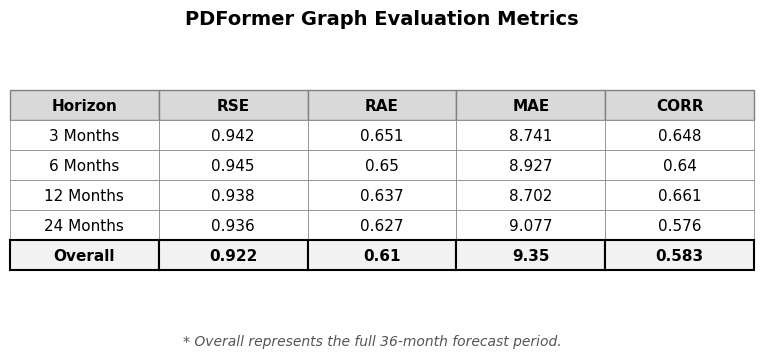

Saved: Graph_Eval_Table.png (and archived to archive/)


In [3]:
print("--- Step 2: Evaluating Model on Test Set ---")
%run Evaluate_Graph.py

print("\n--- PUBLICATION PREVIEW: Evaluation Metrics ---")
visualise_evaluation_metrics()


## Step 3: Visualise Results

This section executes the visualization pipeline to interpret the PDFormer model's output. The process is divided into a **Setup Step** followed by **4 Visualization Cells**, each providing a different level of analytical depth:

* **Setup:** Loads the model predictions (`predictions.npy`), the raw historical dataset (CSV), and the graph structure (`graph.csv`) into a memory object (`vis_data`).
* **Vis 1: Broad Analysis (Dataset-Wide):**
    * *Forecast Accuracy:* Plots "Ground Truth vs Prediction" for every node to assess general model performance.
    * *Gap Analysis:* Plots "Threat vs Mitigation" for every pair in the graph for the forecast window (2023–2025) to identify immediate risks.
* **Vis 2: Validation (Figure 3):** Generates the specific publication-ready plots for key validation nodes (e.g., Password Attack, NLP/LLM).
* **Vis 3: Trend Tables (Tables 5 & 6):** Quantifies the gaps to list the Top 5 "Widening Gaps" (Risks) and "Narrowing Gaps" (Successes).
* **Vis 4: Long-Term Trends (Figure 4):** Stitches history and forecast (2011–2025) to visualize the continuous evolution of major threats.



### Setup & Data Loading
This cell initialises the visualisation pipeline by loading the three critical datasets required for analysis:
1.  **Historical Data (`Cyber_Trend_Forecasting_All.csv`):** The raw dataset containing the 11-year history (2011–2025) of all cyber terms.
2.  **Model Forecasts (`predictions.npy`):** The output tensor from the PDFormer model containing the 36-month future predictions (2023–2025).
3.  **Knowledge Graph (`graph.csv`):** The adjacency matrix defining the relationships between specific **Threats** (e.g., DDoS) and their corresponding **Mitigations** (e.g., IDS/IPS).

These data sources are merged into a single `vis_data` object, which serves as the input for all subsequent visualizations.

In [ ]:
current_dir = Path.cwd()
if str(current_dir.parent) not in sys.path: sys.path.append(str(current_dir.parent))

# Load data into vis_data
vis_data = load_visualisation_data()

if vis_data: print("Data Loaded Successfully.")
else: print("Failed to load data.")

### Broad Analysis: Global Trends
This cell generates two high-level aggregate plots to assess the overall state of the cybersecurity landscape:

* **Global Forecast Accuracy:** Compares the **Global Average Ground Truth** (Black) against the **Global Average Prediction** (Blue) across all nodes. This provides a macroscopic view of the model's reliability.
* **Global Gap Analysis (Threat Intensity vs Mitigation Maturity):** Plots the **Average Threat Intensity** (Red) against the **Average Mitigation Maturity** (Green) for the entire dataset.
    * **Risk Gap (Red Shading):** Indicates periods where threats generally outpace available solutions.
    * **Safety Margin (Green Shading):** Indicates periods where defense maturity exceeds threat intensity.



--- FORECAST ACCURACY: Ground Truth vs Prediction ---
Generated Plot: Global Forecast Accuracy


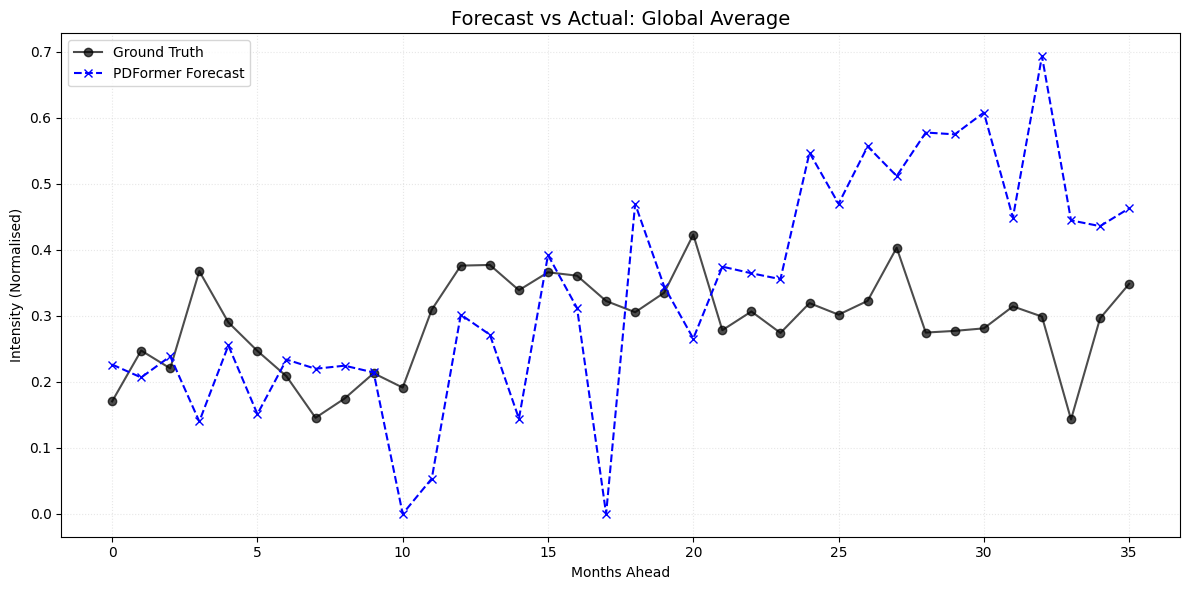


--- GAP ANALYSIS: Threat vs Mitigation ---
Generated Plot: Global Gap Analysis


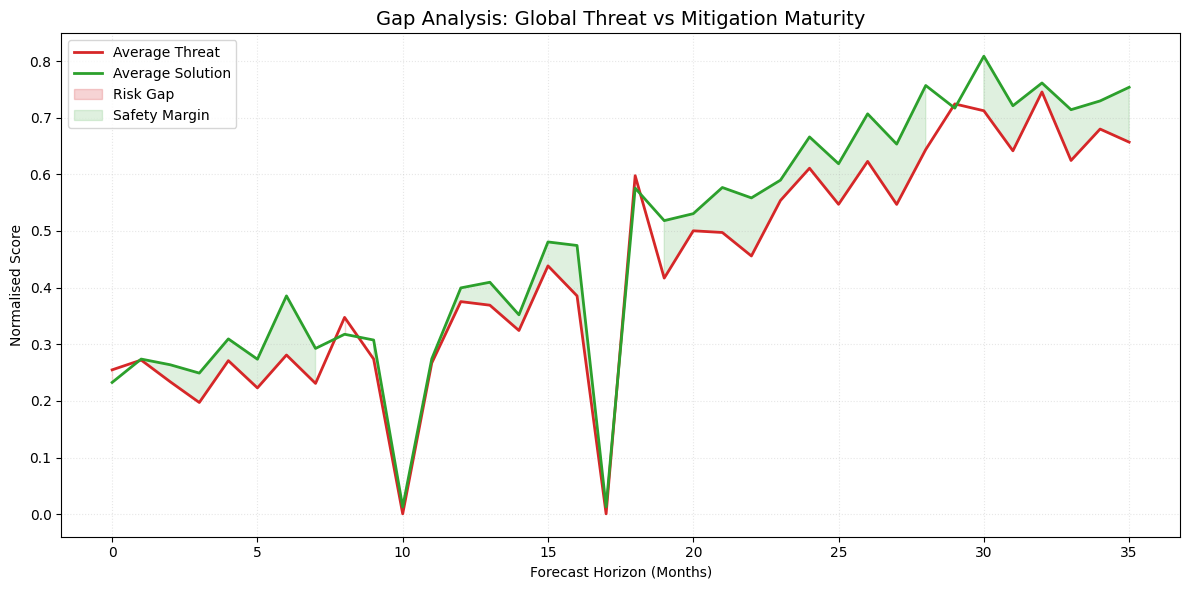

In [ ]:
if vis_data:
    perform_broad_analysis(vis_data)

### Forecast Accuracy (Ground Truth vs Prediction)
This cell generates the validation plots corresponding to **Figure 3** in the paper. It visualises the model's performance on specific, high-priority validation nodes (e.g., *Password Attack*, *NLP/LLM*, *Data Backups*).

* **Visuals:** It plots the **Actual Ground Truth** (Blue Line) versus the **PDFormer Forecast** (Red Dashed Line) over the test period.
* **Confidence:** The shaded region represents the **95% Confidence Interval** of the prediction.


--- Figure 3: Forecast Accuracy (Ground Truth vs Prediction) ---


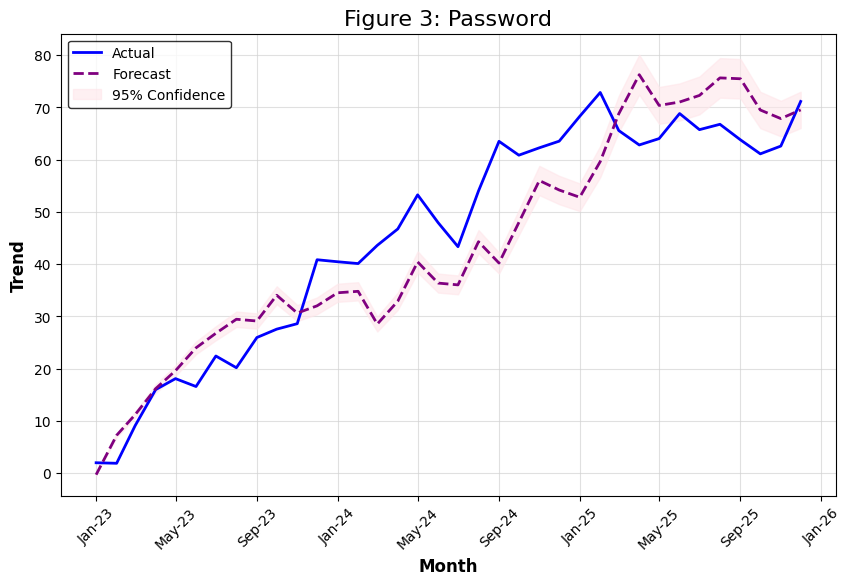

Saved: Fig3_Password.png (and archived to archive/)


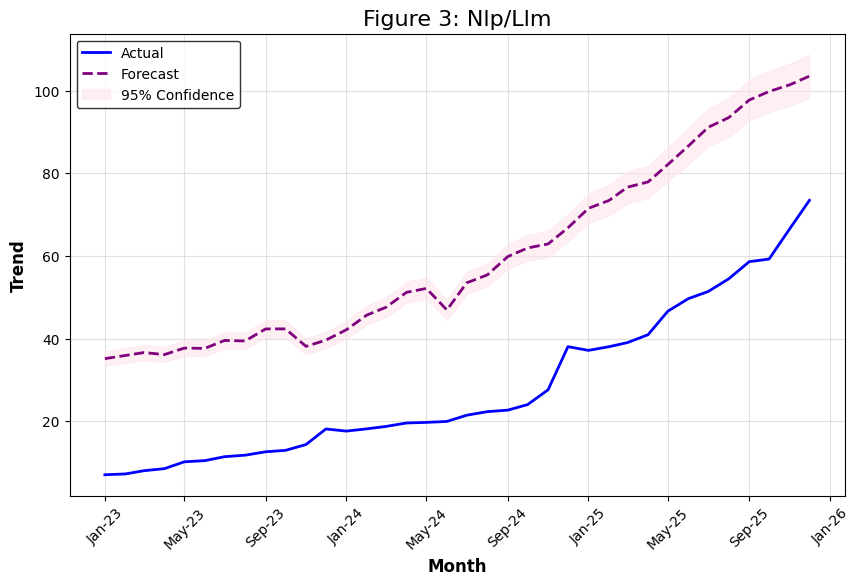

Saved: Fig3_Nlp_Llm.png (and archived to archive/)


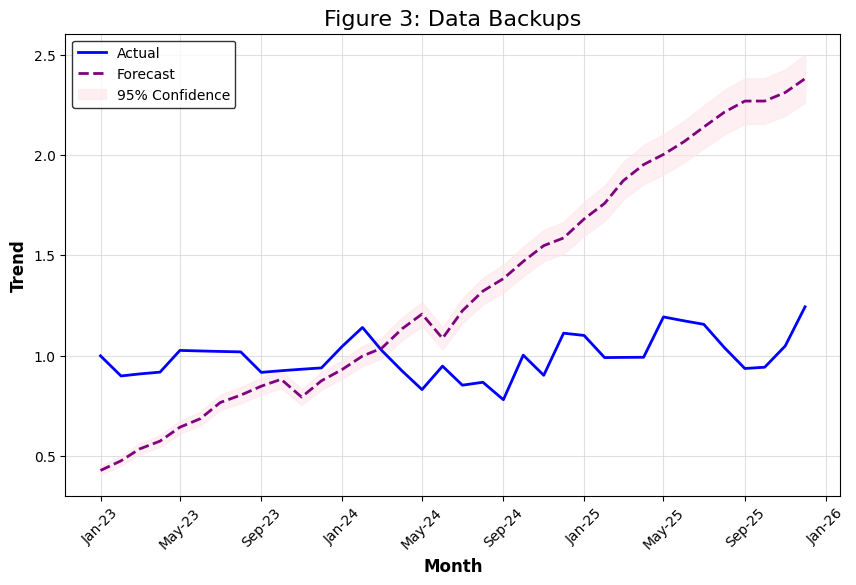

Saved: Fig3_Data_Backups.png (and archived to archive/)


In [4]:
if vis_data:
    plot_validation_forecasts(vis_data)

### Gap Analysis Tables (Tables 5 & 6)
This cell performs a quantitative analysis of the "Risk Gap" defined in the paper. It calculates the numerical difference between Threat Intensity and Solution Maturity for every pair in the knowledge graph over the forecast window (2023–2025).

* **Table 5 (Widening Gaps):** Identifies pairs where the gap is increasing year-over-year (Strictly Widening) or is larger at the end of the period than the start (Overall Widening). These represent emerging risks.
* **Table 6 (Narrowing Gaps):** Identifies pairs where the gap is decreasing, indicating "Success Stories" where mitigation strategies are effectively catching up to the threat.


--- GAP TABLES: Widening & Narrowing ---


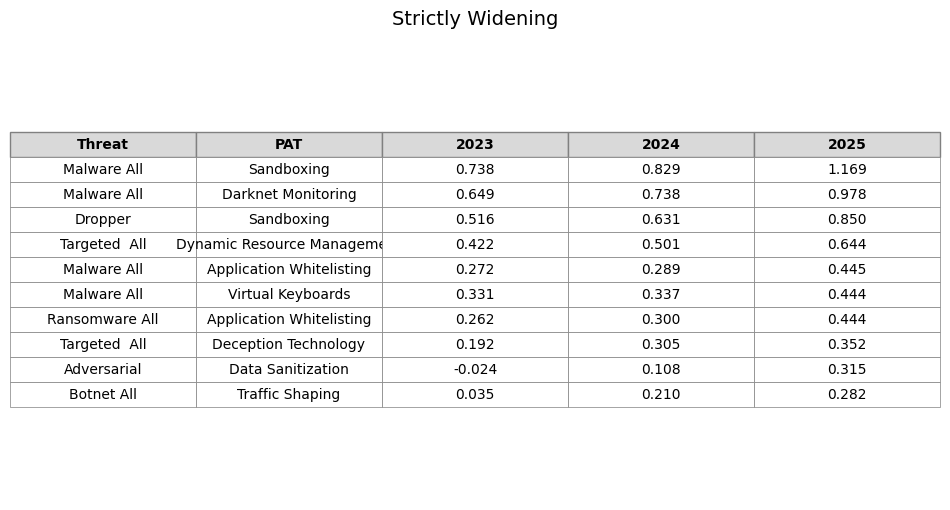

Saved: Strictly_Widening.png (and archived to archive/)

--- Table 5a: Strictly Widening Gaps (Top 5) ---
       Threat                         PAT  2023  2024  2025
  Malware All                  Sandboxing 0.738 0.829 1.169
  Malware All          Darknet Monitoring 0.649 0.738 0.978
      Dropper                  Sandboxing 0.516 0.631 0.850
Targeted  All Dynamic Resource Management 0.422 0.501 0.644
  Malware All    Application Whitelisting 0.272 0.289 0.445


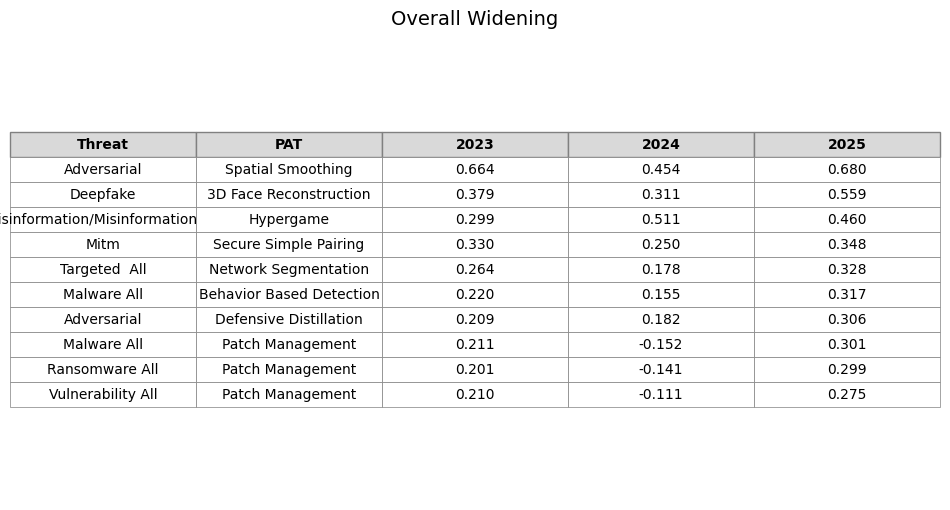

Saved: Overall_Widening.png (and archived to archive/)

--- Table 5b: Overall Widening Gaps (Top 5) ---
                           Threat                    PAT  2023  2024  2025
                      Adversarial      Spatial Smoothing 0.664 0.454 0.680
                         Deepfake 3D Face Reconstruction 0.379 0.311 0.559
Disinformation/Misinformation All              Hypergame 0.299 0.511 0.460
                             Mitm  Secure Simple Pairing 0.330 0.250 0.348
                    Targeted  All   Network Segmentation 0.264 0.178 0.328


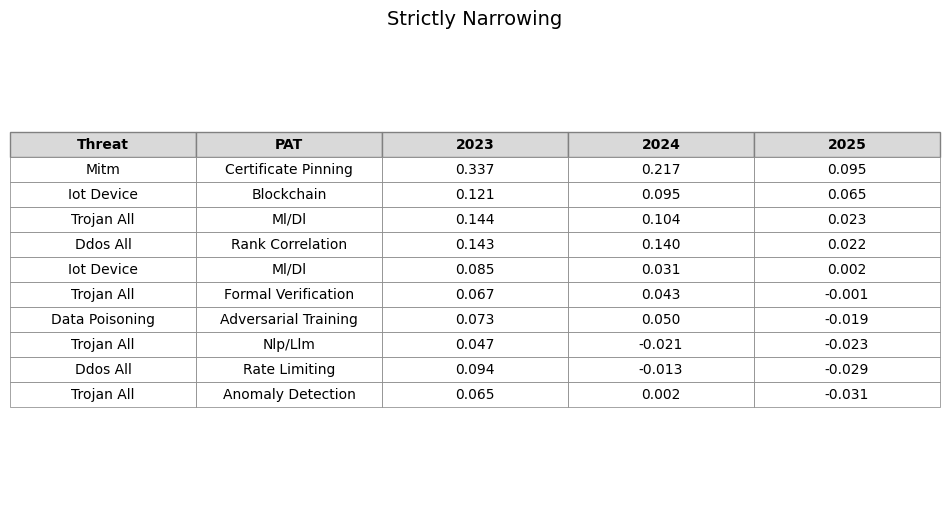

Saved: Strictly_Narrowing.png (and archived to archive/)

--- Table 6a: Strictly Narrowing Gaps (Top 5) ---
    Threat                 PAT  2023  2024  2025
      Mitm Certificate Pinning 0.337 0.217 0.095
Iot Device          Blockchain 0.121 0.095 0.065
Trojan All               Ml/Dl 0.144 0.104 0.023
  Ddos All    Rank Correlation 0.143 0.140 0.022
Iot Device               Ml/Dl 0.085 0.031 0.002


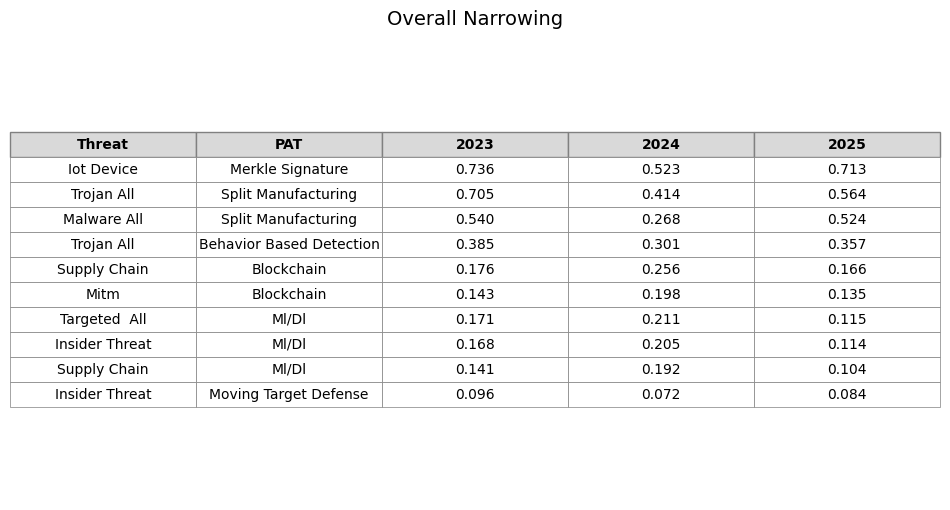

Saved: Overall_Narrowing.png (and archived to archive/)

--- Table 6b: Overall Narrowing Gaps (Top 5) ---
      Threat                      PAT  2023  2024  2025
  Iot Device         Merkle Signature 0.736 0.523 0.713
  Trojan All      Split Manufacturing 0.705 0.414 0.564
 Malware All      Split Manufacturing 0.540 0.268 0.524
  Trojan All Behavior Based Detection 0.385 0.301 0.357
Supply Chain               Blockchain 0.176 0.256 0.166


In [6]:
if vis_data:
  generate_gap_analysis_tables(vis_data)

### Continuous Trends (2011–2028)
This cell generates **Figure 4**, which stitches the historical data (2011–2022) with the model's forecast (2023–2028) to visualise the continuous 14-year evolution of major threat vectors (e.g., *Malware*, *Ransomware*).

* **The Trend:** The Black Line represents the continuous trend from the past into the future.
* **The Forecast:** The future period (2023–2025) includes 95% confidence shading.
* **Mitigation Context:** Where applicable, relevant solution trends (Green/Blue lines) are plotted alongside the threat to visualise the long-term interaction between attack vectors and defense mechanisms.


--- PAPER FIG 4: Continuous Trends ---


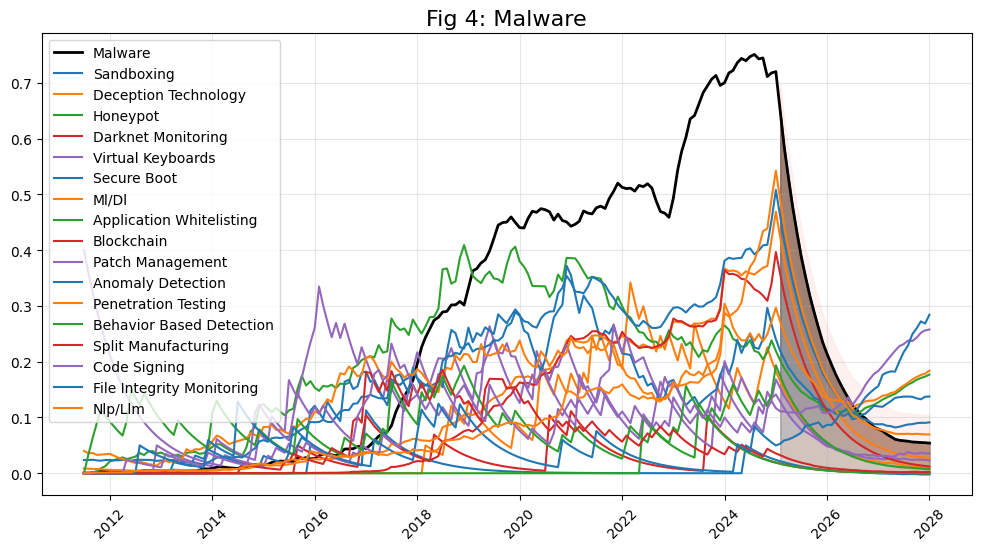

Saved: Fig4_Malware.png (and archived to archive/)


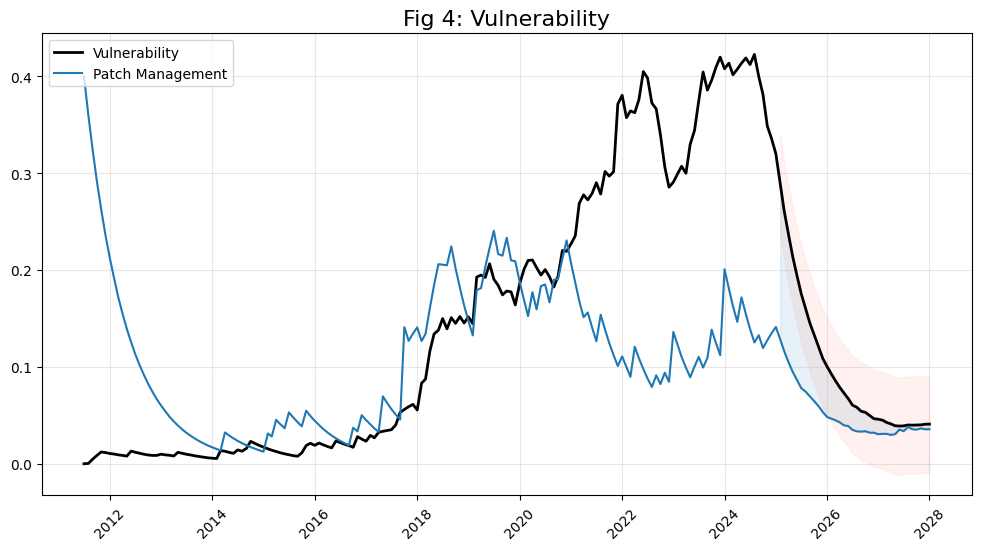

Saved: Fig4_Vulnerability.png (and archived to archive/)


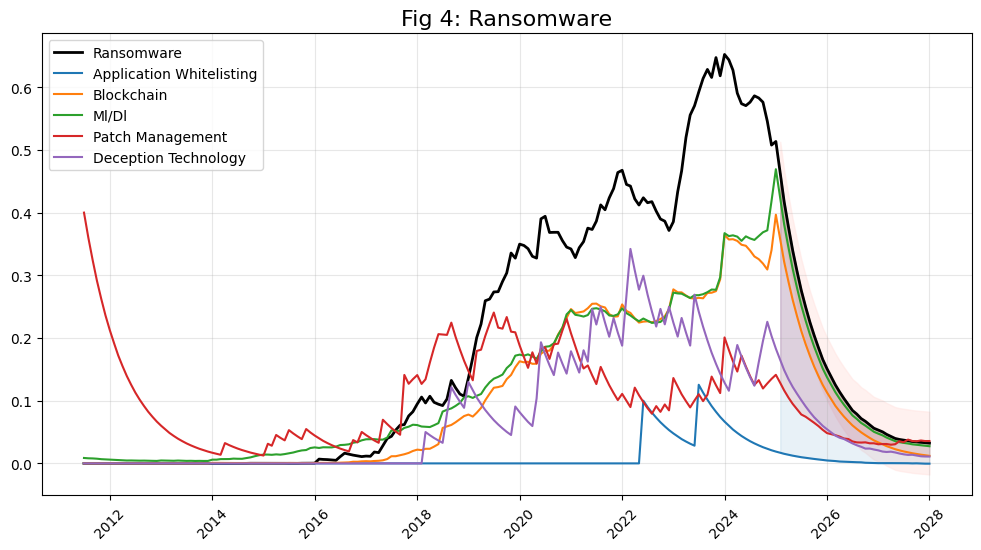

Saved: Fig4_Ransomware.png (and archived to archive/)


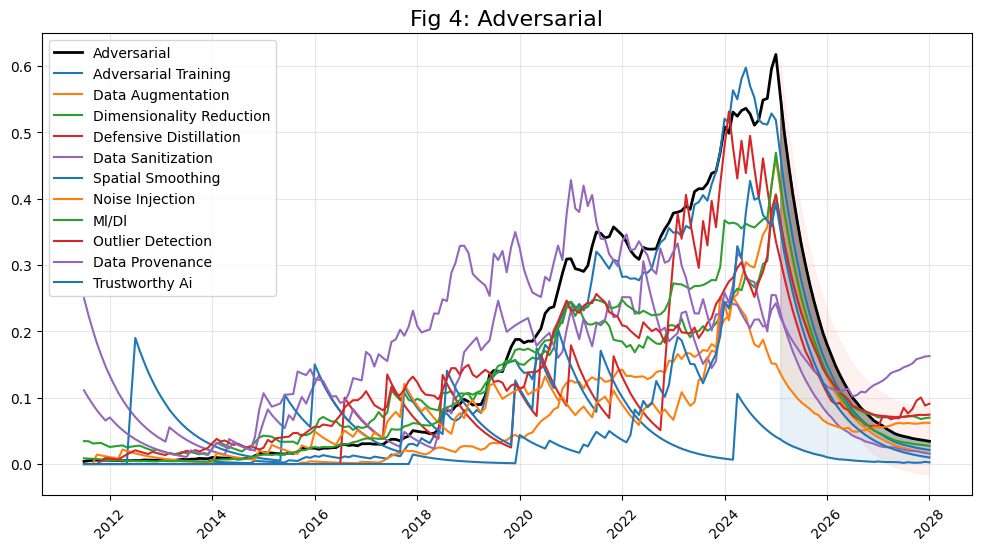

Saved: Fig4_Adversarial.png (and archived to archive/)


In [ ]:
if vis_data:
    plot_continuous_trends(vis_data)

### Execute Full Pipeline
This cell executes the entire `Visualise_Results.py` script in one go using the `%run` command.

Using `%run` here ensures that the visualisation functions and loaded data remain accessible in the notebook session for further inspection if needed.


--- Loading Visualisation Data ---
Loading Full History from: /content/drive/MyDrive/Research/NATO/code/Cyber-trend-forecasting/Data_Preparation/Cyber_Trend_Forecasting_All.csv

--- FORECAST ACCURACY: Ground Truth vs Prediction ---


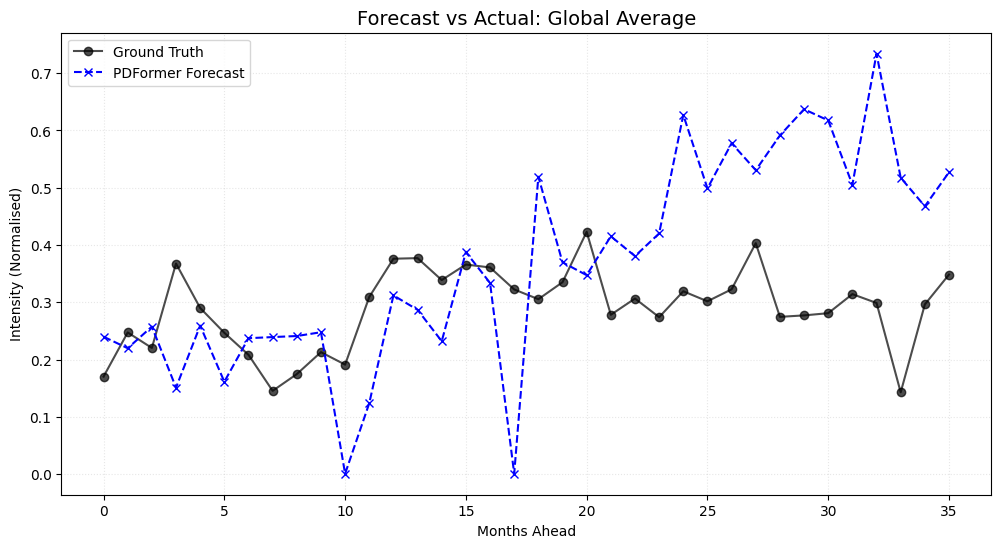

Saved: Global_Forecast_Accuracy.png (and archived to archive/)

--- GAP ANALYSIS: Threat vs Mitigation ---


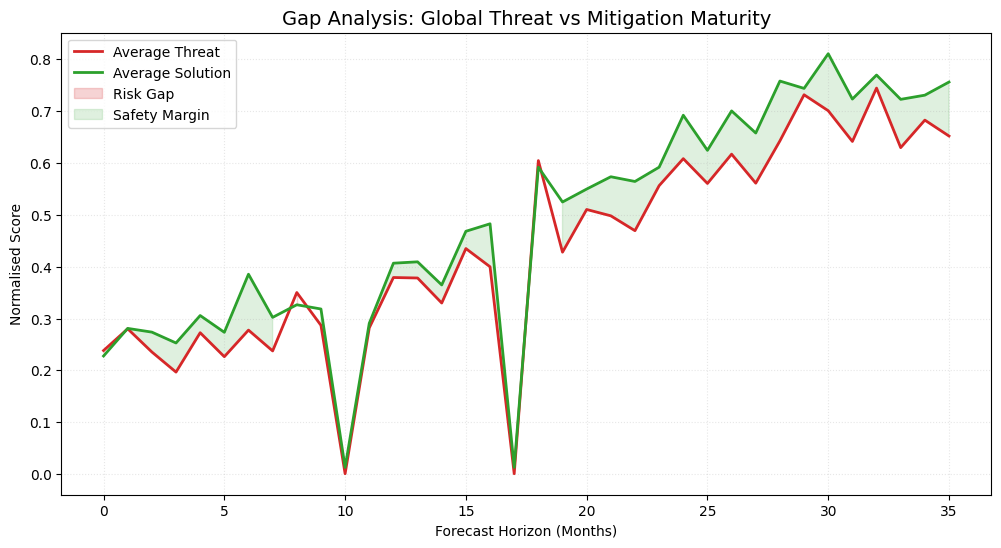

Saved: Global_Gap_Analysis.png (and archived to archive/)

--- Figure 3: Forecast Accuracy (Ground Truth vs Prediction) ---


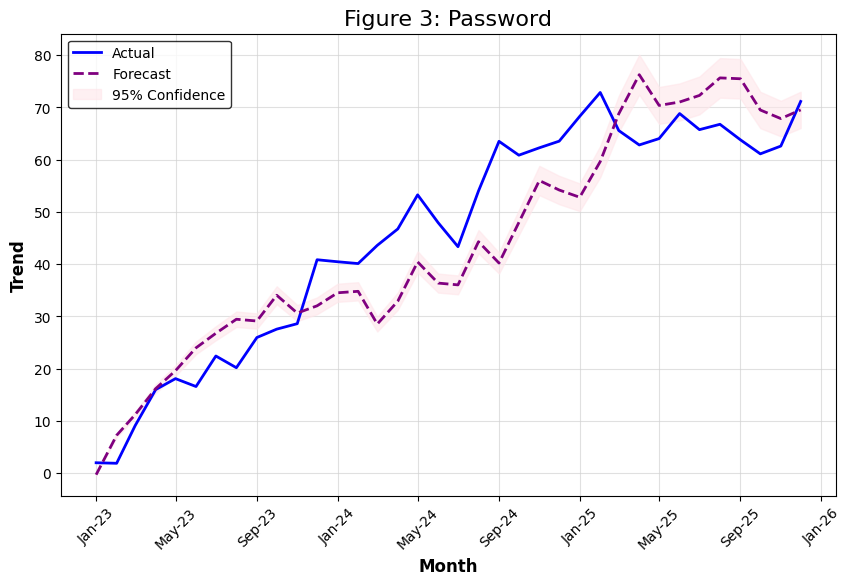

Saved: Fig3_Password.png (and archived to archive/)


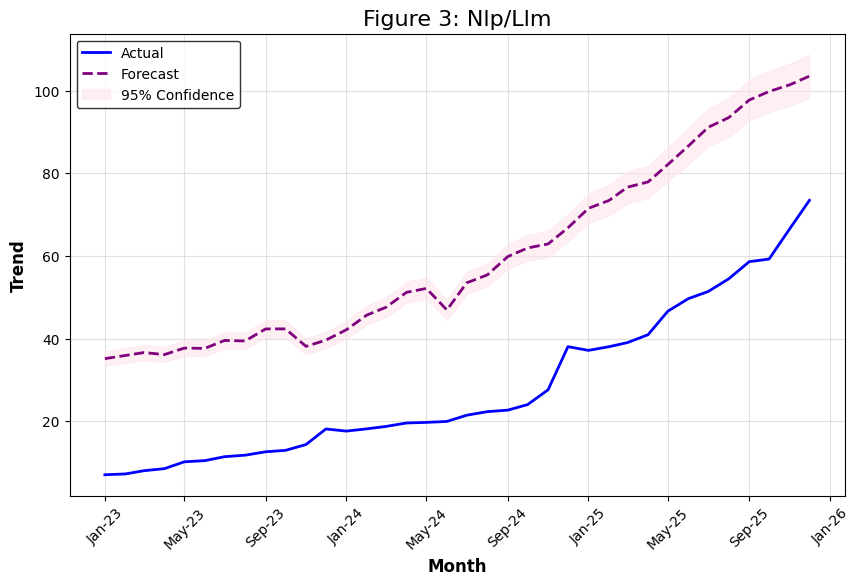

Saved: Fig3_Nlp_Llm.png (and archived to archive/)


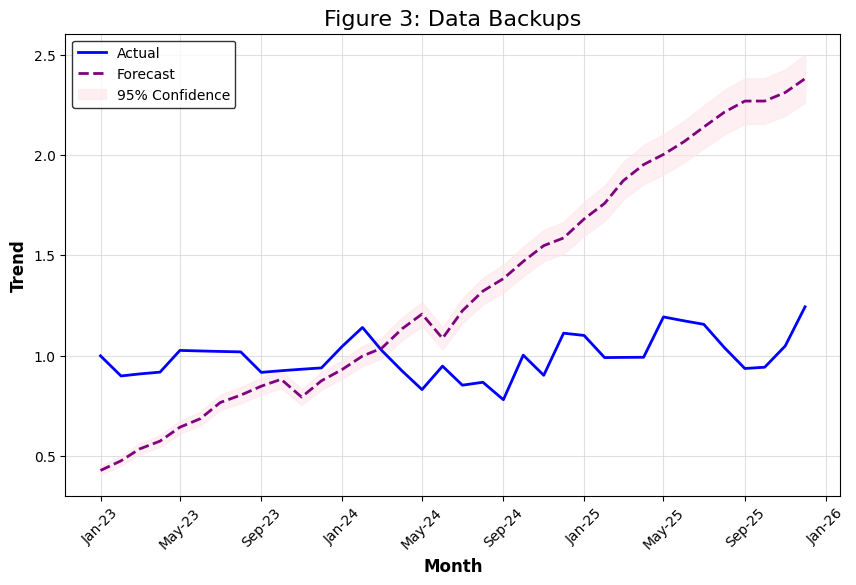

Saved: Fig3_Data_Backups.png (and archived to archive/)

--- GAP TABLES: Widening & Narrowing ---


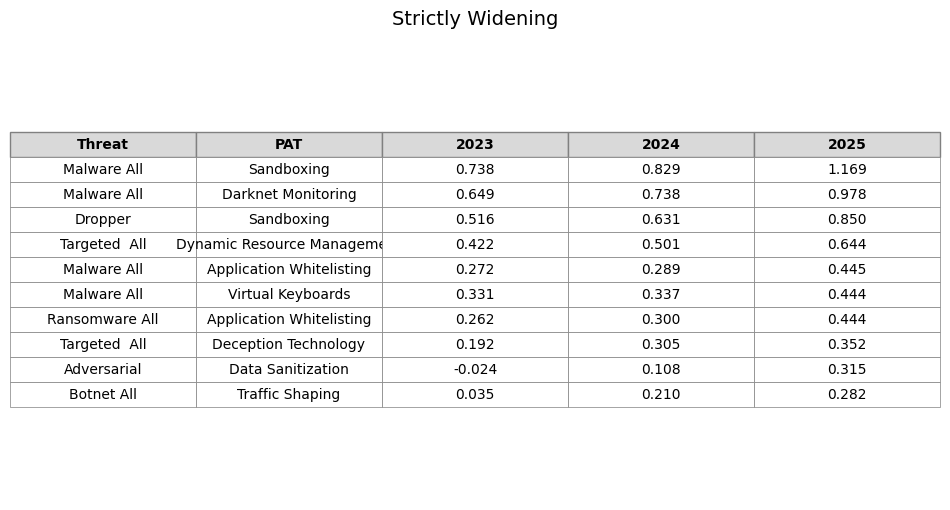

Saved: Strictly_Widening.png (and archived to archive/)

--- Table 5a: Strictly Widening Gaps (Top 5) ---
       Threat                         PAT  2023  2024  2025
  Malware All                  Sandboxing 0.738 0.829 1.169
  Malware All          Darknet Monitoring 0.649 0.738 0.978
      Dropper                  Sandboxing 0.516 0.631 0.850
Targeted  All Dynamic Resource Management 0.422 0.501 0.644
  Malware All    Application Whitelisting 0.272 0.289 0.445


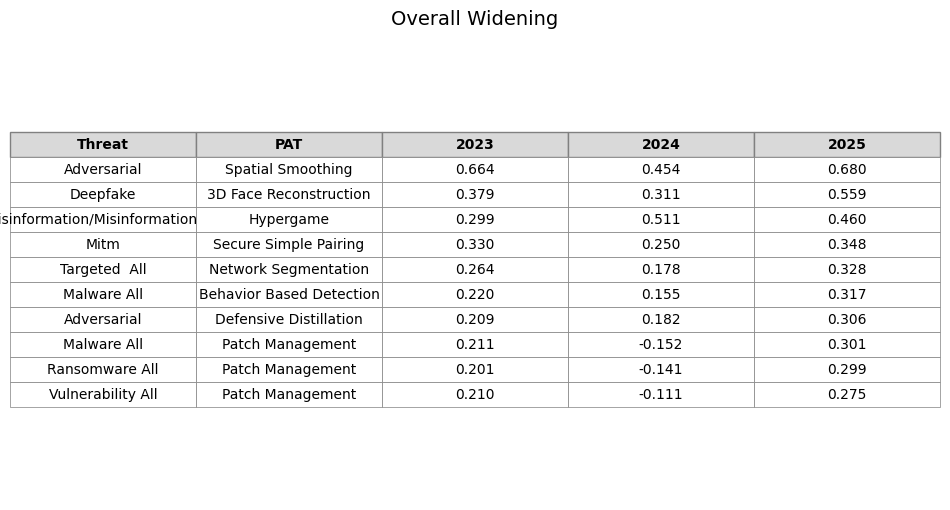

Saved: Overall_Widening.png (and archived to archive/)

--- Table 5b: Overall Widening Gaps (Top 5) ---
                           Threat                    PAT  2023  2024  2025
                      Adversarial      Spatial Smoothing 0.664 0.454 0.680
                         Deepfake 3D Face Reconstruction 0.379 0.311 0.559
Disinformation/Misinformation All              Hypergame 0.299 0.511 0.460
                             Mitm  Secure Simple Pairing 0.330 0.250 0.348
                    Targeted  All   Network Segmentation 0.264 0.178 0.328


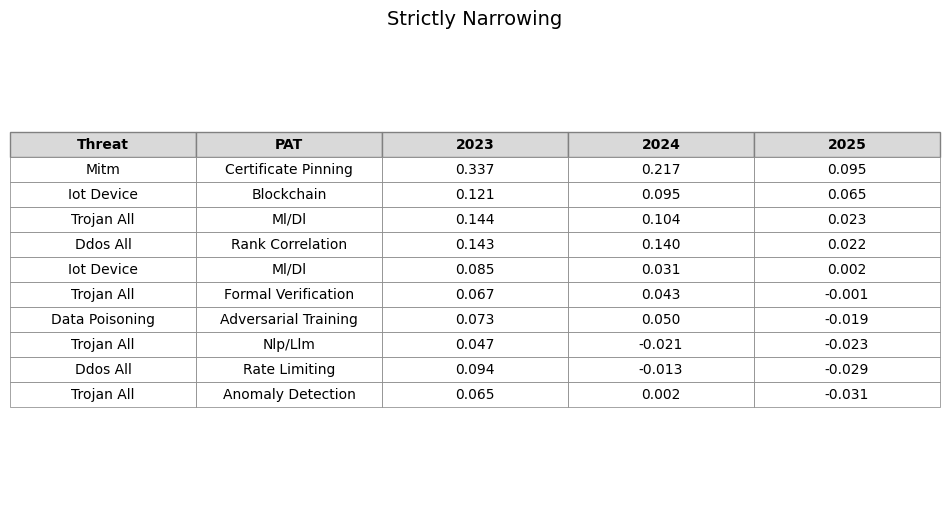

Saved: Strictly_Narrowing.png (and archived to archive/)

--- Table 6a: Strictly Narrowing Gaps (Top 5) ---
    Threat                 PAT  2023  2024  2025
      Mitm Certificate Pinning 0.337 0.217 0.095
Iot Device          Blockchain 0.121 0.095 0.065
Trojan All               Ml/Dl 0.144 0.104 0.023
  Ddos All    Rank Correlation 0.143 0.140 0.022
Iot Device               Ml/Dl 0.085 0.031 0.002


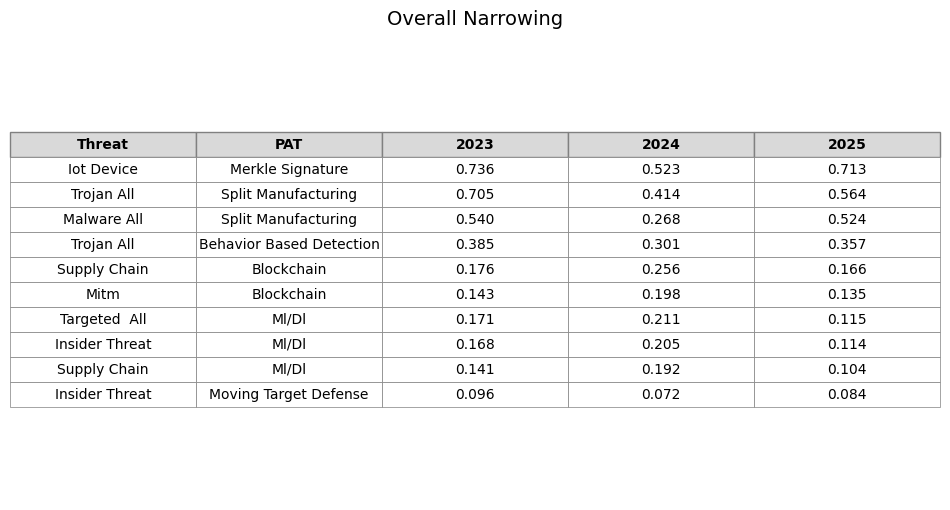

Saved: Overall_Narrowing.png (and archived to archive/)

--- Table 6b: Overall Narrowing Gaps (Top 5) ---
      Threat                      PAT  2023  2024  2025
  Iot Device         Merkle Signature 0.736 0.523 0.713
  Trojan All      Split Manufacturing 0.705 0.414 0.564
 Malware All      Split Manufacturing 0.540 0.268 0.524
  Trojan All Behavior Based Detection 0.385 0.301 0.357
Supply Chain               Blockchain 0.176 0.256 0.166

--- PAPER FIG 4: Continuous Trends ---


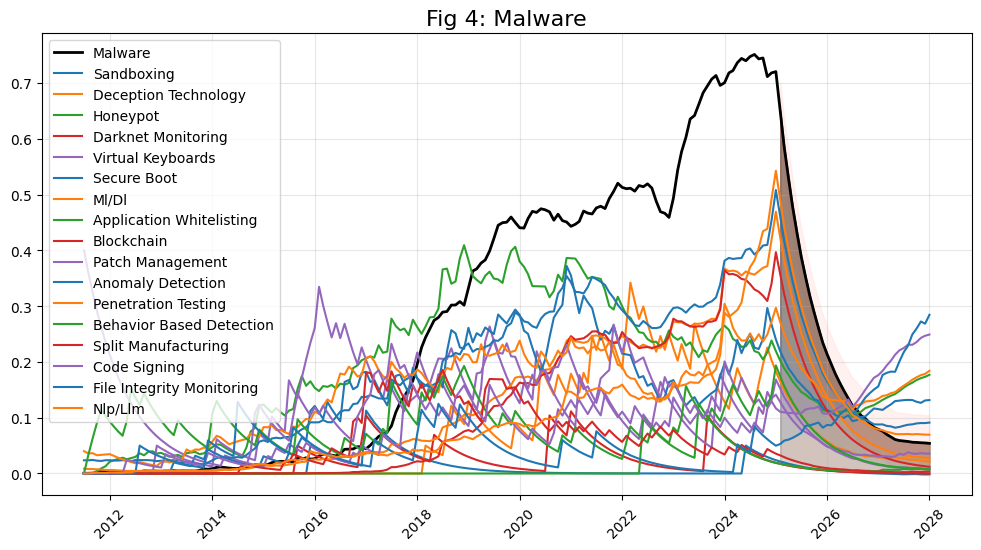

Saved: Fig4_Malware.png (and archived to archive/)


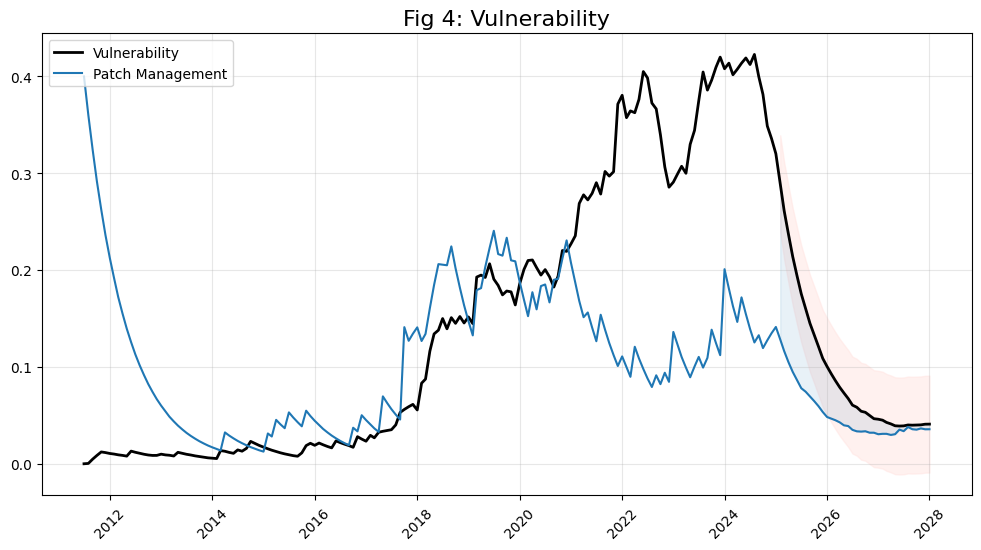

Saved: Fig4_Vulnerability.png (and archived to archive/)


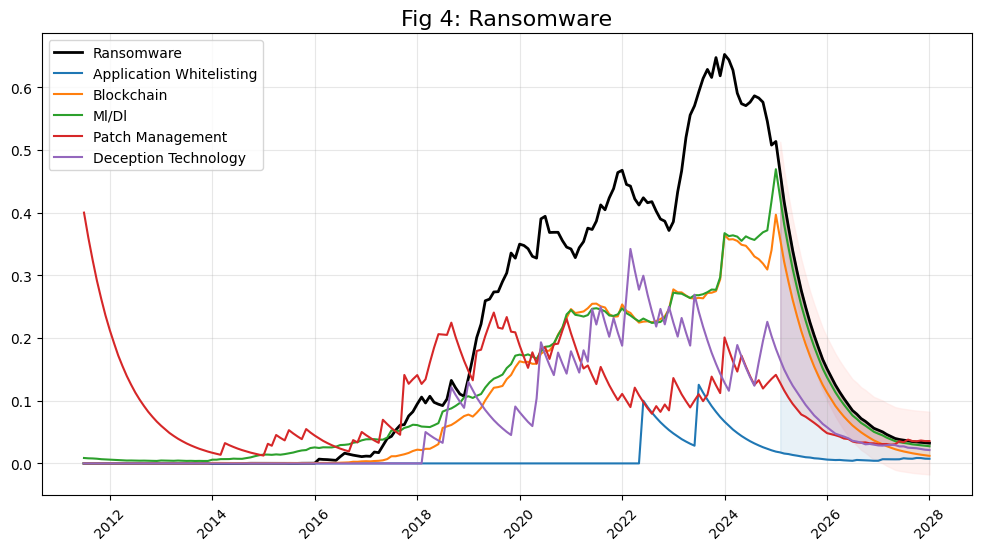

Saved: Fig4_Ransomware.png (and archived to archive/)


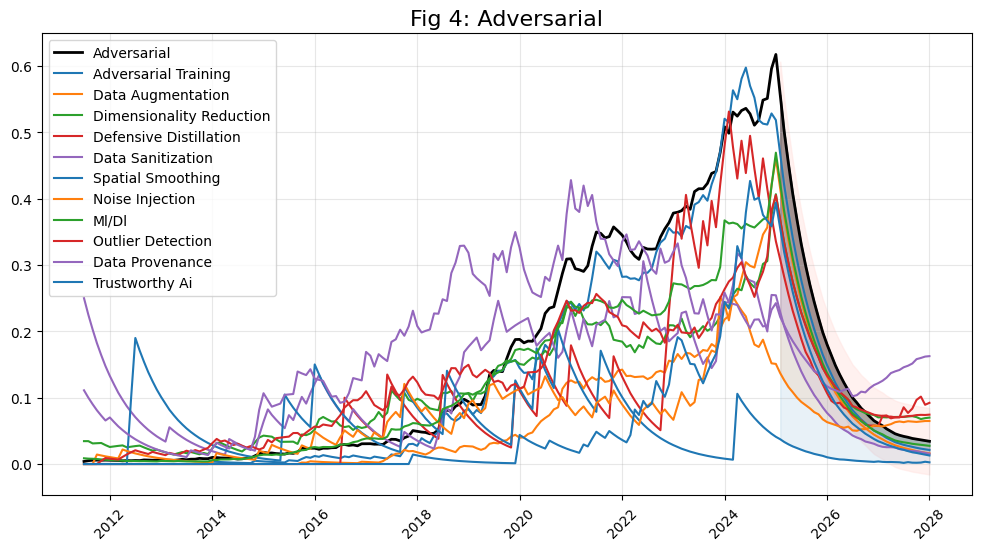

Saved: Fig4_Adversarial.png (and archived to archive/)


<Figure size 640x480 with 0 Axes>

In [5]:
%run Visualise_Results.py